## Import + load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
master_df = pd.read_csv(os.path.join(base_dir, 'data', 'processed', 'master_df.csv'), index_col=0)

print("✅ Libraries loaded")
print(f"✅ master_df loaded — {master_df.shape}")

✅ Libraries loaded
✅ master_df loaded — (3, 19)


## Define Market Sizing Data

In [4]:
# TAM, CAGR, PE capital deployed — sourced from IHRSA, PitchBook, IBISWorld
market_data = {
    'HVLP': {
        'TAM_B':        20.0,    # $20B total addressable market
        'CAGR':         6.7,     # % annual growth
        'PE_Capital_B': 3.5,     # $B PE capital deployed 2019–2024
        'Locations':    3200,    # US location count (Planet Fitness ~2400 + others)
        'Members_M':    21.0,    # total members in millions
        'Avg_Rev_Site': 1.8,     # avg annual revenue per site $M
    },
    'Boutique': {
        'TAM_B':        5.4,
        'CAGR':         12.8,    # higher growth rate despite smaller TAM
        'PE_Capital_B': 1.5,
        'Locations':    8500,    # fragmented — F45, Orangetheory, Club Pilates etc
        'Members_M':    6.2,
        'Avg_Rev_Site': 0.6,
    },
    'Digital': {
        'TAM_B':        8.1,
        'CAGR':         3.2,     # slowing post-COVID
        'PE_Capital_B': 0.2,
        'Locations':    0,       # no physical locations
        'Members_M':    9.8,     # app/platform users
        'Avg_Rev_Site': 0,
    },
}

categories = list(market_data.keys())
colors = {'HVLP': '#4f98a3', 'Boutique': '#f97316', 'Digital': '#a78bfa'}

for cat, d in market_data.items():
    sam = d['TAM_B'] * 0.35   # serviceable addressable market ~35% of TAM
    som = sam * 0.12           # serviceable obtainable market ~12% of SAM
    d['SAM_B'] = round(sam, 2)
    d['SOM_B'] = round(som, 2)
    print(f"{cat:<10}  TAM: ${d['TAM_B']}B  |  SAM: ${d['SAM_B']}B  |  SOM: ${d['SOM_B']}B  |  CAGR: {d['CAGR']}%  |  PE: ${d['PE_Capital_B']}B")

HVLP        TAM: $20.0B  |  SAM: $7.0B  |  SOM: $0.84B  |  CAGR: 6.7%  |  PE: $3.5B
Boutique    TAM: $5.4B  |  SAM: $1.89B  |  SOM: $0.23B  |  CAGR: 12.8%  |  PE: $1.5B
Digital     TAM: $8.1B  |  SAM: $2.83B  |  SOM: $0.34B  |  CAGR: 3.2%  |  PE: $0.2B


## TAM/SAM/SOM Funnel Chart

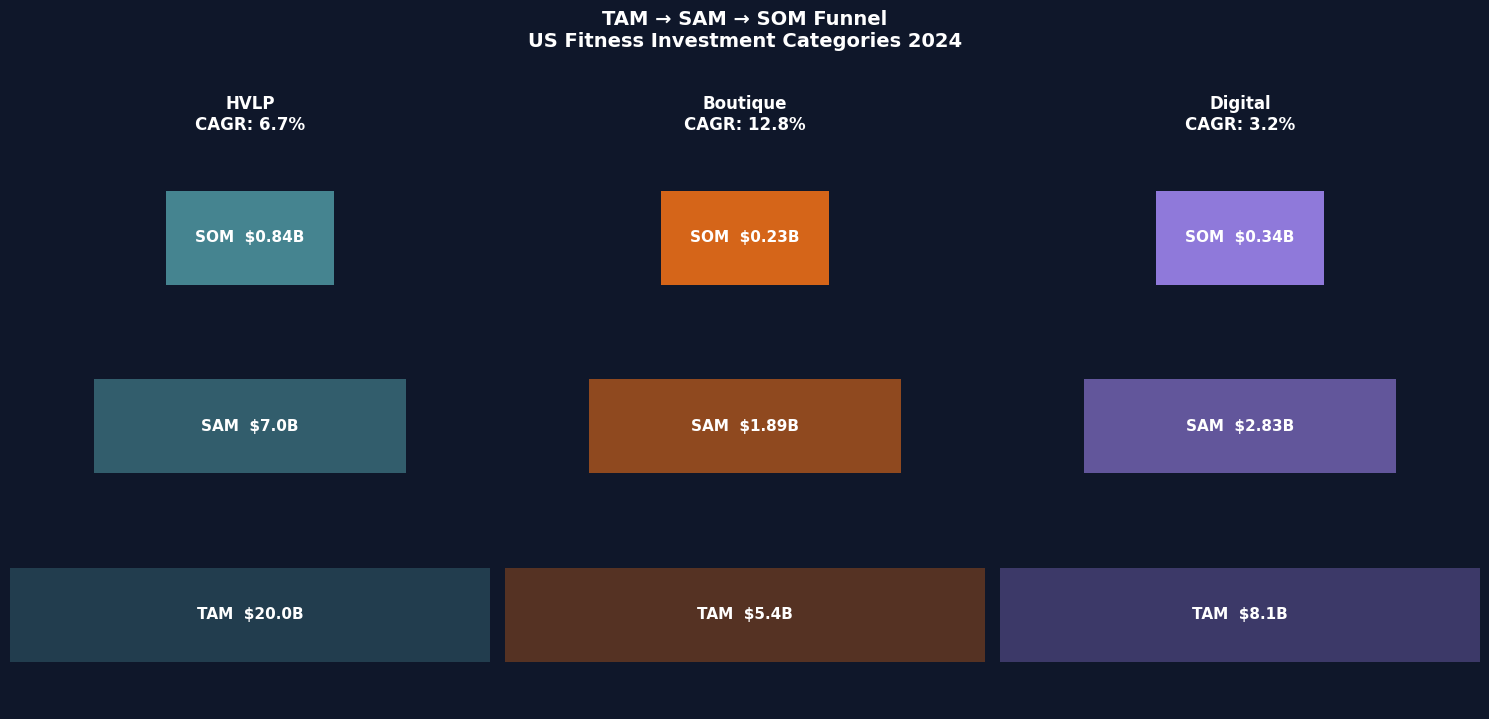

✅ TAM/SAM/SOM funnel saved → output/tam_sam_som.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor('#0f172a')

for ax, cat in zip(axes, categories):
    ax.set_facecolor('#0f172a')
    d = market_data[cat]
    color = colors[cat]

    levels   = ['TAM', 'SAM', 'SOM']
    values   = [d['TAM_B'], d['SAM_B'], d['SOM_B']]
    widths   = [1.0, 0.65, 0.35]
    alphas   = [0.3, 0.55, 0.85]

    for i, (lbl, val, w, alpha) in enumerate(zip(levels, values, widths, alphas)):
        bar = ax.barh(i, w, height=0.5, color=color, alpha=alpha,
                      left=(1 - w) / 2, align='center')
        ax.text(0.5, i, f'{lbl}  ${val}B',
                ha='center', va='center',
                color='white', fontsize=11, fontweight='bold')

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, 2.5)
    ax.axis('off')
    ax.set_title(f'{cat}\nCAGR: {d["CAGR"]}%',
                 color='white', fontsize=12, fontweight='bold', pad=10)

fig.suptitle('TAM → SAM → SOM Funnel\nUS Fitness Investment Categories 2024',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'tam_sam_som.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ TAM/SAM/SOM funnel saved → output/tam_sam_som.png")